In [36]:
from neuland_add_random_hitpar import NeulandRandHitParAdder as ParAdder
from ROOT import TFile
import pandas as pd
import numpy as np
import seaborn as sns

In [37]:
NUMBER_OF_BARS = 1300
par_adder = ParAdder(NUMBER_OF_BARS)

In [38]:
COS_PERIOD = 1000
par_adder.effective_speed.set_cos( offset = 10., amp = 5., period = COS_PERIOD, err = 0.5)
par_adder.t_sync.set_cos( offset = 15., amp = 5, period = COS_PERIOD, err = 0.5)
par_adder.t_diff.set_cos( offset = 0., amp = 3., period = COS_PERIOD, err = 0.5)
par_adder.light_attenuation_length.set_cos( offset = 0.008, amp = 0.004, period = COS_PERIOD, err = 0.0005)
par_adder.energy_gain.set_cos( offset = 15., amp = 5., period = COS_PERIOD, err = 0.5)
par_adder.pedestal.set_cos( offset = 25., amp = 5., period = COS_PERIOD, err = 0.5)
par_adder.pmt_thresh.set_cos( offset = 0.75, amp = 0.25, period = COS_PERIOD, err = 0.5)
par_adder.saturation_coefficient.set_cos( offset = 0.5, amp = 0.4, period = COS_PERIOD, err = 0.5)

In [39]:
input_filename = "/u/yanwang/git_forks/R3BRoot/build/bin/sim.par.root.0"
output_filename = "/u/yanwang/git_forks/R3BRoot/build/bin/added_sim.par.root.0"
par_adder.insert_parameters(input_filename, output_filename);

Warning in <TGeoManager::Init>: Deleting previous geometry: FAIRGeom/FAIR geometry
Info in <TGeoManager::CloseGeometry>: Geometry loaded from file...
Info in <TGeoManager::SetTopVolume>: Top volume is cave. Master volume is cave
Info in <TGeoManager::Voxelize>: Voxelizing...
Info in <TGeoManager::CountLevels>: max level = 3, max placements = 1300
Info in <TGeoManager::CloseGeometry>: 5202 nodes/ 6 volume UID's in FAIR geometry
Info in <TGeoManager::CloseGeometry>: ----------------modeler ready----------------


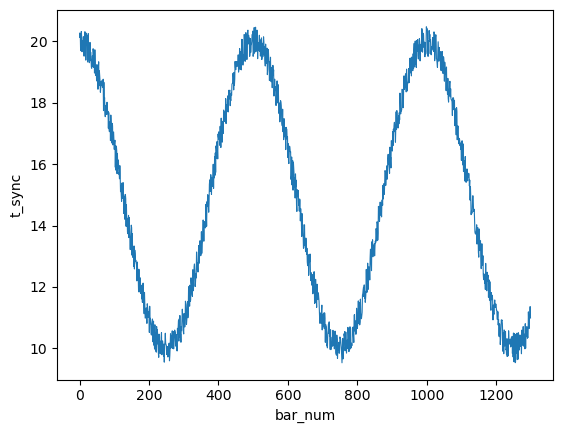

In [43]:
# Checking the output
output_file = TFile(output_filename, "read")
hit_par = output_file.Get("NeulandHitPar")
t_syncs = np.zeros(NUMBER_OF_BARS)
t_diffs = np.zeros(NUMBER_OF_BARS)
light_attenuation_lengths = np.zeros(NUMBER_OF_BARS)
energy_gain = np.zeros(NUMBER_OF_BARS)
pedestals = np.zeros(NUMBER_OF_BARS)
pmt_threshs = np.zeros(NUMBER_OF_BARS)
saturation_coefficients = np.zeros(NUMBER_OF_BARS)

for bar_num in range(NUMBER_OF_BARS):
    t_syncs[bar_num] = hit_par.GetModuleParAt(bar_num).tSync.value
    t_diffs[bar_num] = hit_par.GetModuleParAt(bar_num).tDiff.value
    light_attenuation_lengths[bar_num] = hit_par.GetModuleParAt(bar_num).lightAttenuationLength.value
    energy_gain[bar_num] = hit_par.GetModuleParAt(bar_num).energyGain.left().value
    pedestals[bar_num] = hit_par.GetModuleParAt(bar_num).pedestal.left()
    pmt_threshs[bar_num] = hit_par.GetModuleParAt(bar_num).PMTThreshold.left().value
    saturation_coefficients[bar_num] = hit_par.GetModuleParAt(bar_num).PMTSaturation.left().value

data_frame = pd.DataFrame({"bar_num": range(NUMBER_OF_BARS), "t_sync": t_syncs})

sns.lineplot(data = data_frame, x = 'bar_num', y = 't_sync', linewidth = 0.8);

In [ ]:
input_cal_par = "/lustre/r3b/ywang/test/neuland_test/millepede/cal.par.root"